In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

df = pd.read_json("../data/dataset.json")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1550 entries, 0 to 1549
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   titulo       1550 non-null   object
 1   descripcion  1550 non-null   object
 2   tags         1550 non-null   object
 3   categoria    1550 non-null   object
dtypes: object(4)
memory usage: 48.6+ KB


### LISTA DE TODAS LAS ETIQUETAS (TAGS) ÚNICAS

In [2]:
todos_los_tags = [tag for lista in df['tags'] for tag in lista]
conteo_tags = Counter(todos_los_tags)

df_tags = pd.DataFrame(conteo_tags.items(), columns=['Tag', 'Cantidad']).sort_values(by='Cantidad', ascending=False).reset_index(drop=True)

total_apariciones = df_tags['Cantidad'].sum()
df_tags['Porcentaje'] = (df_tags['Cantidad'] / total_apariciones * 100).round(2).astype(str) + '%'

display(df_tags)

,Tag,Cantidad,Porcentaje
0,python,236,5.49%
1,javascript,146,3.4%
2,php,130,3.02%
3,java,113,2.63%
4,sql,102,2.37%
...,...,...,...
593,gcloud,1,0.02%
594,descargar,1,0.02%
595,repositorio,1,0.02%
596,netcat,1,0.02%


## TOP 10 DE TAGS

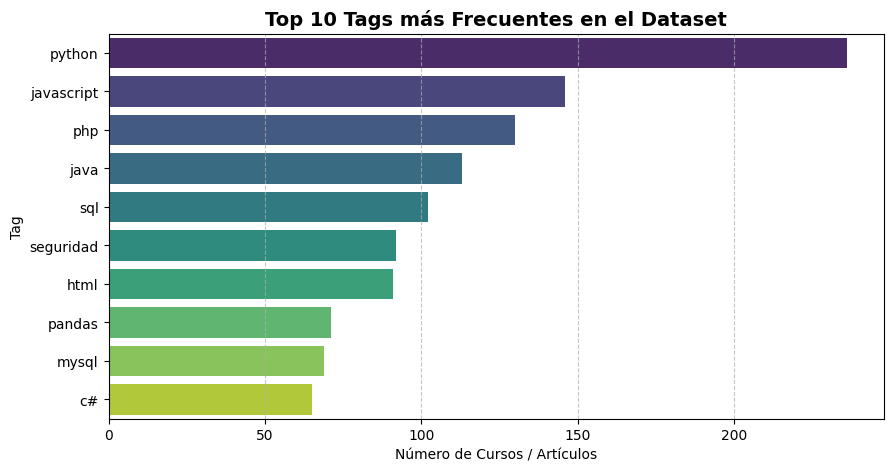

In [3]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_tags.head(10),
    x='Cantidad',
    y='Tag',
    hue='Tag',
    palette='viridis',
    legend=False
)
plt.title('Top 10 Tags más Frecuentes en el Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Número de Cursos / Artículos')
plt.ylabel('Tag')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## DISTRIBUCIÓN DE LONGITUD DE DESCRIPCIÓN

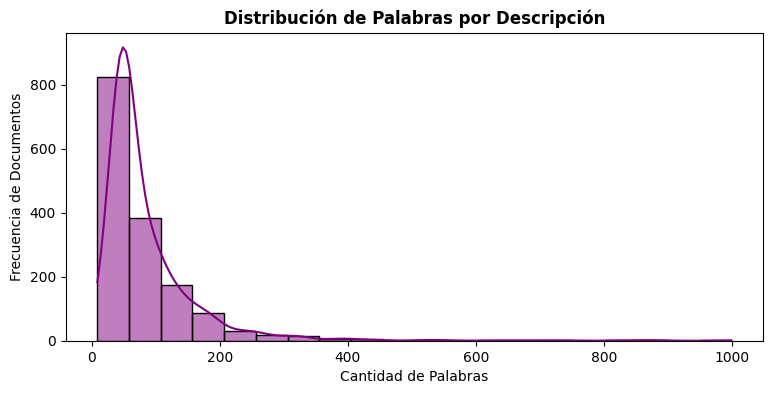


--- Resumen Estadístico de las Descripciones ---
count    1550.000000
mean       85.910323
std        80.431015
min         9.000000
25%        46.000000
50%        55.000000
75%       100.000000
max       999.000000
Name: cant_palabras_desc, dtype: float64


In [4]:
df['cant_palabras_desc'] = df['descripcion'].fillna('').apply(lambda x: len(str(x).split()))

plt.figure(figsize=(9, 4))
sns.histplot(df['cant_palabras_desc'], bins=20, kde=True, color='purple')
plt.title('Distribución de Palabras por Descripción', fontsize=12, fontweight='bold')
plt.xlabel('Cantidad de Palabras')
plt.ylabel('Frecuencia de Documentos')
plt.show()

print("\n--- Resumen Estadístico de las Descripciones ---")
print(df['cant_palabras_desc'].describe())

plt.show()

### Interpretación del gráfico
* **Distribución Unimodal Sesgada:** Tras la consolidación del dataset a un total de **1,550** documentos, el comportamiento cambia a una distribución unimodal con marcada asimetría positiva (sesgo a la derecha). La gran mayoría de los registros se concentran en textos relativamente breves, alcanzando un pico máximo de frecuencia cerca de las **50** palabras (más de 800 documentos se sitúan en el rango inicial).
* **Tendencia Central:** La mediana se ubica en **55.0** palabras por descripción, lo que refleja que la mitad de los textos son bastante concisos. El promedio general sube hasta **85.9** palabras debido al peso de las descripciones más largas de la cola derecha.
* **Presencia de Outliers y Dispersión:** Existe una dispersión notable (desviación estándar de **80.4** palabras). El 75% del dataset tiene **100** palabras o menos, pero la cola derecha se extiende ampliamente desde un mínimo de **9** palabras hasta un valor atípico máximo (outlier) de **999** palabras.